# Analysis and Forecasting of Financial Time Series  
## Global Spillovers between US and Indian Equity Markets

---

**Dataset:** Daily data of S&P 500, NIFTY 50, USD/INR, and VIX  
**Period:** September 2007 to Present  
**Frequency:** Daily  

---

## The Basic Idea

In this project, we follow one simple concept:

> **Data = Signal + Noise**

That means every time series can be thought of as:
- some meaningful pattern (signal)
- some random part (noise)

Our goal is to remove all the patterns step by step, so that in the end, only **pure randomness (white noise)** is left.

---

## What is White Noise?

A series is called white noise if:

- It has **no pattern in mean** → no autocorrelation  
- It has **no pattern in variance** → no volatility clustering  

In simple terms, nothing should be predictable from past values.

---

## How We Extract Signal

We remove structure in two steps:

| Stage | Model | What it captures | What we check |
|------|------|------------------|--------------|
| 1 | VAR | Relationships between variables (mean) | Residual ACF |
| 2 | GARCH | Volatility patterns (variance) | Squared residual ACF |

If both checks show no pattern, we can say that the remaining series is just noise.

---

## Research Questions

In this project, we try to answer:

1. Do US and Indian markets move together in the long run?  
2. Does the US market affect the Indian market in the short run?  
3. Does global uncertainty (VIX) influence both markets?  
4. How long does volatility last after a shock?  

---

## Step 1: Data Collection

We collect daily data for:

- S&P 500 (US market)
- NIFTY 50 (Indian market)
- USD/INR exchange rate
- VIX (global fear index)

These variables allow us to study cross-market interactions.

In [1]:
import sys
sys.path.append('..')

from src.fetch_data import fetch_data

data = fetch_data()
data.head()

,SP500,NIFTY,USDINR,VIX
Date,,,,
2007-09-17,1476.650024,4494.649902,40.376999,26.480000
2007-09-18,1519.780029,4546.200195,40.216999,20.350000
2007-09-19,1529.030029,4732.350098,40.033001,20.030001
2007-09-20,1518.750000,4747.549805,39.615002,20.450001
2007-09-21,1525.750000,4837.549805,39.770000,19.000000


## Step 2: Initial Inspection

We first check for missing values and dataset size.

In [2]:
print(data.isnull().sum())
print("Observations:", len(data))

SP500     0
NIFTY     0
USDINR    0
VIX       0
dtype: int64
Observations: 4100


## Step 3: Transforming to Returns

Financial prices are non-stationary.

We convert them into **log returns**, which represent percentage changes:

r(t) = log(P(t)) - log(P(t-1))

This helps stabilize variance and remove trends.

In [3]:
import numpy as np

returns = np.log(data).diff().dropna()
returns.head()

,SP500,NIFTY,USDINR,VIX
Date,,,,
2007-09-18,0.028790,0.011404,-0.003971,-0.263309
2007-09-19,0.006068,0.040130,-0.004586,-0.015850
2007-09-20,-0.006746,0.003207,-0.010496,0.020752
2007-09-21,0.004598,0.018780,0.003905,-0.073544
2007-09-24,-0.005270,0.019377,-0.008561,0.019287


## Step 4: Visualizing the Data

We compare price levels and returns.

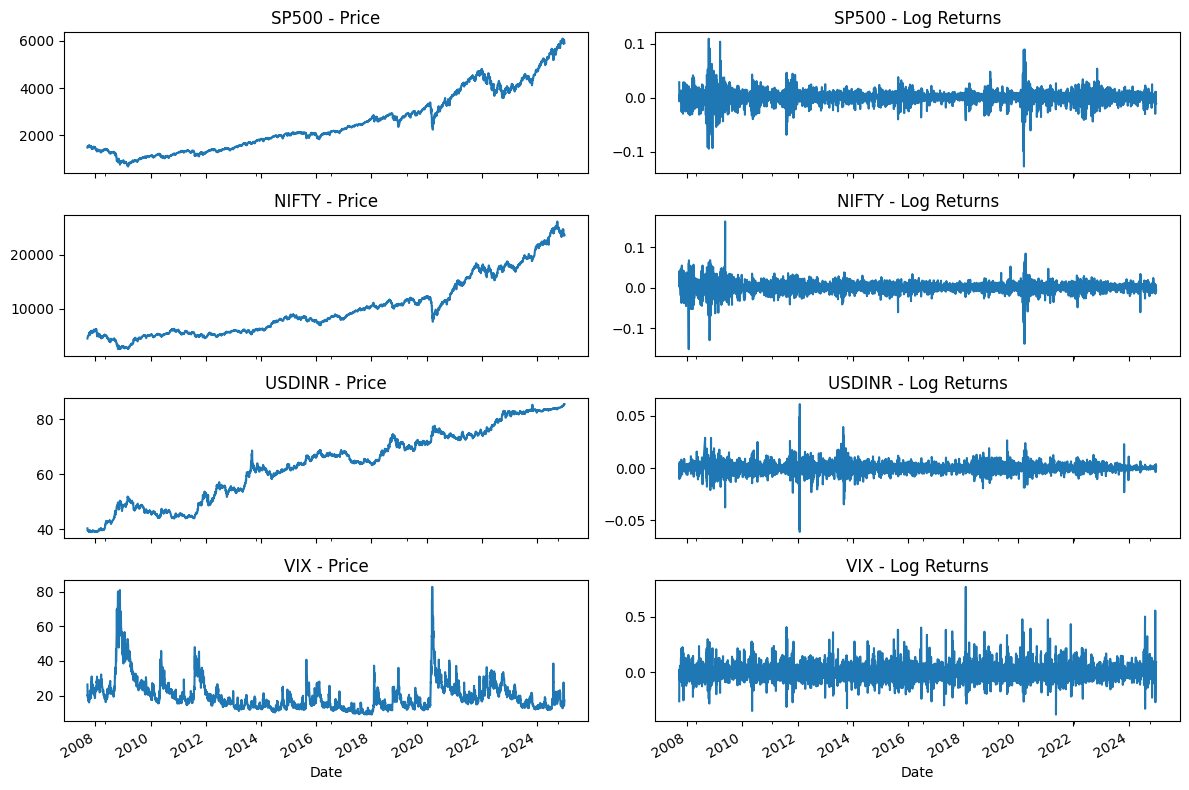

In [8]:
import matplotlib.pyplot as plt

cols = data.columns
n = len(cols)

fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 8), sharex=True)

for i, col in enumerate(cols):
    data[col].plot(ax=axes[i, 0], title=f"{col} - Price")
    returns[col].plot(ax=axes[i, 1], title=f"{col} - Log Returns")

plt.tight_layout()
plt.show()

## Step 5: Stationarity Testing

We use two tests:

- ADF → tests for unit root
- KPSS → tests for stationarity

A series is stationary only if:
- ADF rejects non-stationarity
- KPSS does not reject stationarity

In [9]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

def test_stationarity(series):
    adf_p = adfuller(series)[1]
    kpss_p = kpss(series, nlags='auto')[1]
    return adf_p, kpss_p

results = {}

for col in returns.columns:
    results[col] = test_stationarity(returns[col])

pd.DataFrame(results, index=["ADF p-value", "KPSS p-value"])

/var/folders/9b/_420w89j6jb0s4_8bvd0kkdh0000gn/T/ipykernel_58788/3172833181.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, nlags='auto')[1]
/var/folders/9b/_420w89j6jb0s4_8bvd0kkdh0000gn/T/ipykernel_58788/3172833181.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, nlags='auto')[1]
/var/folders/9b/_420w89j6jb0s4_8bvd0kkdh0000gn/T/ipykernel_58788/3172833181.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, nlags='auto')[1]
/var/folders/9b/_420w89j6jb0s4_8bvd0kkdh0000gn/T/ipykernel_58788/3172833181.py:6: InterpolationWarning: The test statistic is outs

,SP500,NIFTY,USDINR,VIX
ADF p-value,7.859576e-28,1.944034e-22,0.0,0.0
KPSS p-value,1.000000e-01,1.000000e-01,0.1,0.1


## Step 6: Modeling Mean Dynamics (VAR)

VAR captures how variables influence each other over time.

Example:
- Does S&P 500 affect NIFTY?
- Does VIX affect both markets?

We fit a VAR model on returns.

In [10]:
from statsmodels.tsa.api import VAR

model = VAR(returns)
lag_order = model.select_order(10)
print(lag_order.summary())

var_result = model.fit(2)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -33.80      -33.79   2.097e-15      -33.80
1       -34.05     -34.01*   1.638e-15      -34.03
2       -34.06      -34.00   1.616e-15     -34.04*
3       -34.07      -33.99   1.605e-15      -34.04
4       -34.07      -33.96   1.603e-15      -34.03
5       -34.07      -33.94   1.604e-15      -34.02
6       -34.07      -33.91   1.604e-15      -34.01
7       -34.07      -33.89   1.596e-15      -34.01
8       -34.07      -33.87   1.596e-15      -34.00
9       -34.07      -33.84   1.593e-15      -33.99
10     -34.07*      -33.82  1.591e-15*      -33.98
--------------------------------------------------


/opt/miniconda3/envs/afts_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## Step 7: Checking Residuals

If VAR captured all mean structure:

- Residuals should have no autocorrelation

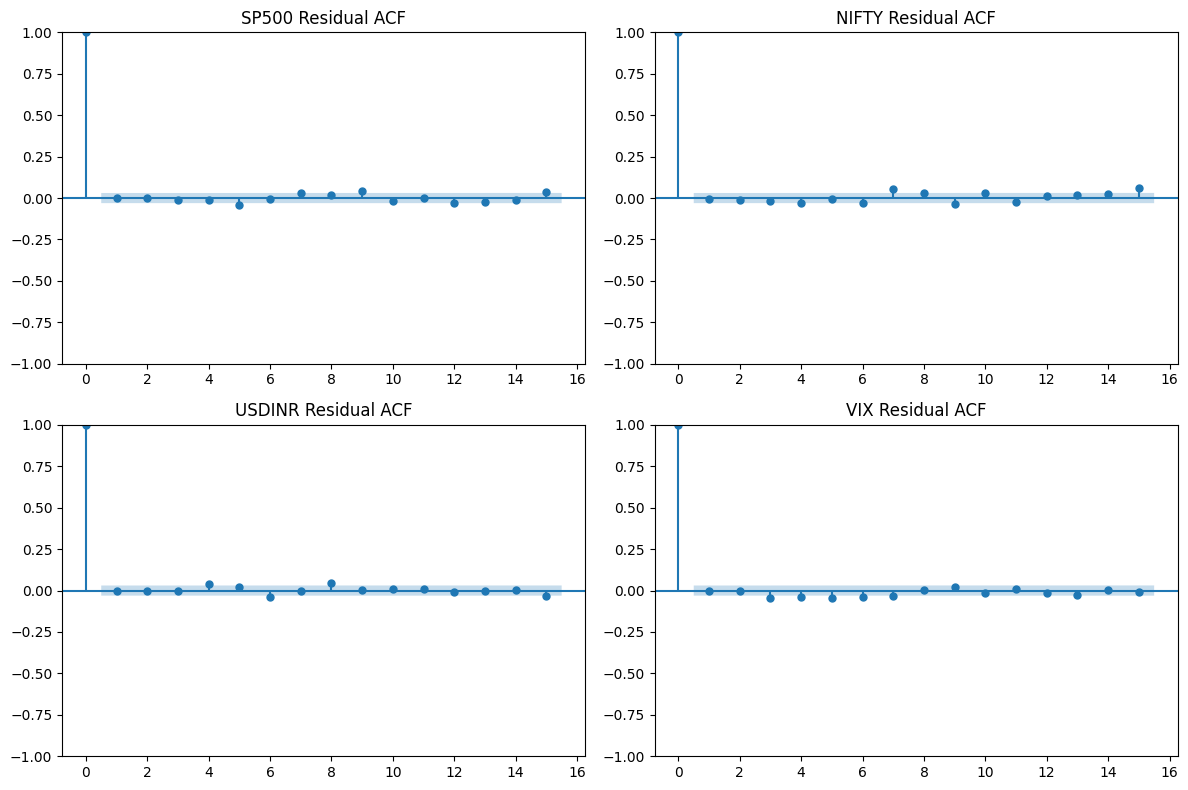

In [15]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

cols = var_result.resid.columns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()  # makes indexing easy

for i, col in enumerate(cols):
    plot_acf(var_result.resid[col], lags=15, ax=axes[i])
    axes[i].set_title(f"{col} Residual ACF")

# Hide unused subplot (since 3 variables → 4 slots)
if len(cols) < len(axes):
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Step 8: Detecting Volatility Clustering

Even if mean is modeled, variance may still have structure.

We test for ARCH effects.

In [16]:
from statsmodels.stats.diagnostic import het_arch

for col in var_result.resid.columns:
    stat, p, _, _ = het_arch(var_result.resid[col])
    print(col, "p-value:", p)

SP500 p-value: 6.822085761175182e-232
NIFTY p-value: 1.8858842345523433e-75
USDINR p-value: 2.46725387982046e-255
VIX p-value: 2.4087804520541837e-28


## Step 9: Modeling Volatility (GARCH)

If ARCH effects exist, we model variance using GARCH.

This captures volatility clustering.

In [17]:
from arch import arch_model

garch_models = {}

for col in var_result.resid.columns:
    model = arch_model(var_result.resid[col], p=1, q=1)
    res = model.fit(disp='off')
    garch_models[col] = res

/opt/miniconda3/envs/afts_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.000165. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/var/folders/9b/_420w89j6jb0s4_8bvd0kkdh0000gn/T/ipykernel_58788/4189809566.py:7: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp='off')
/opt/miniconda3/envs/afts_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001701. Parameter

## Step 10: Final Residual Check

After GARCH, residuals should be white noise.

No structure in:
- residuals
- squared residuals

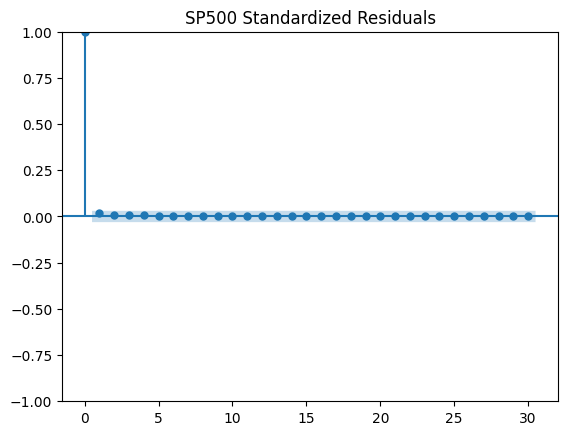

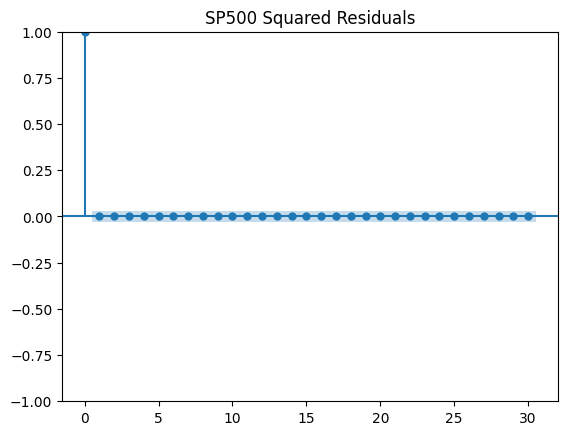

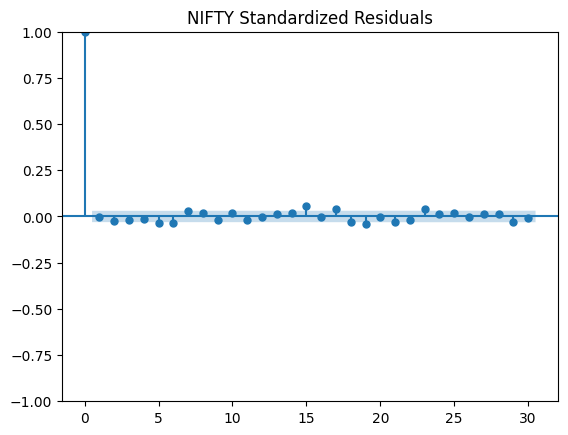

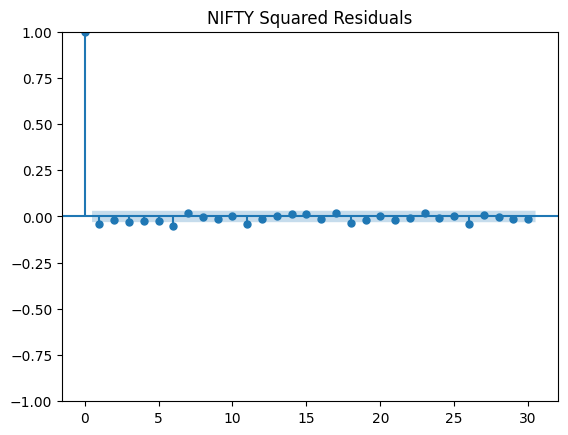

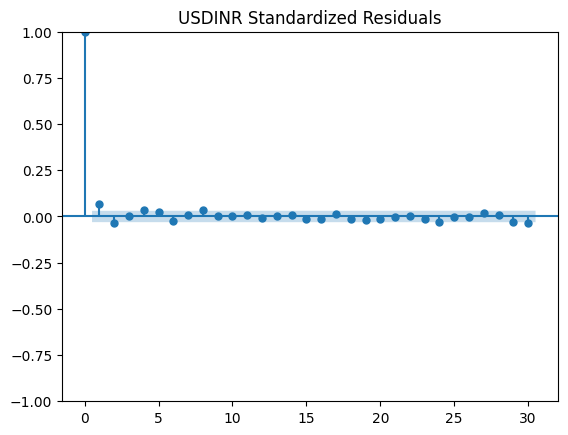

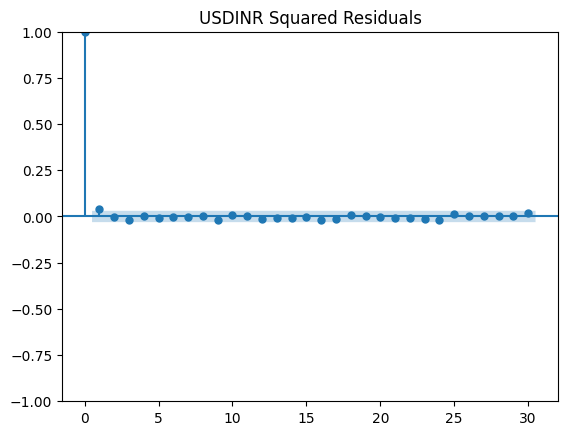

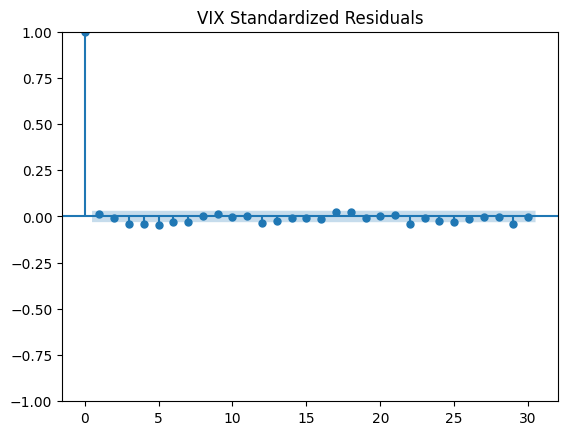

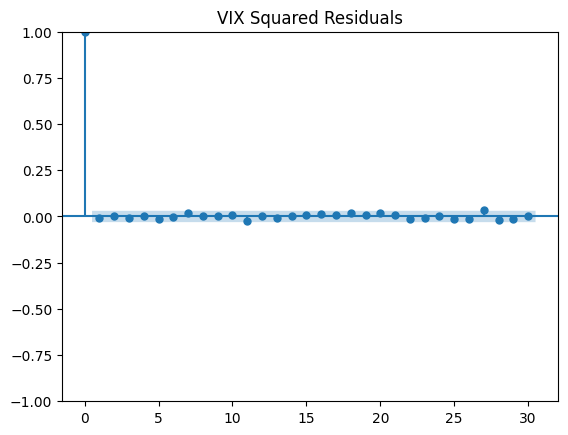

In [18]:
for col in garch_models:
    std_resid = garch_models[col].std_resid

    plot_acf(std_resid, lags=30)
    plt.title(f"{col} Standardized Residuals")
    plt.show()

    plot_acf(std_resid**2, lags=30)
    plt.title(f"{col} Squared Residuals")
    plt.show()

## Step 11: Economic Interpretation

We now interpret relationships using:

- Granger causality → directional influence
- IRF → shock propagation
- FEVD → contribution of shocks

These help us understand global spillovers.

## Final Conclusion

We successfully decomposed:

Data → Signal (VAR + GARCH) + Noise

Findings:

- Markets are interconnected in the short run
- Volatility persists after shocks
- Global fear impacts both markets

Final residuals behave like white noise → model is well specified